# Exploratory Data Analysis on Fake News Detection Dataset

## Summary
This dataset contains **6,000 labeled English news articles** designed for Fake News Detection using Natural Language Processing (**NLP**) and Machine Learning techniques. It includes news headlines, complete article text, category information, publication dates, and binary target labels, making it suitable for building classification models.

Our task is to **analyze misinformation patterns**, evaluate text features, and build classification models to help users accurately distinguish between real and fake news articles.

## Business & Research Objectives
* **Category Concentration:** Which news category (subject) contains the highest concentration of fake news?
* **Temporal Patterns:** How do publication timelines (`date`) correlate with the spread of fake news compared to real news?
* **Linguistic Trends:** What are the most common keywords or linguistic patterns found in fake news headlines versus real news headlines?
* **Article Length:** Does article length differ significantly between fake and real news articles?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Visualization settings
plt.style.use('ggplot')
sns.set_palette("viridis")

In [2]:
df = pd.read_csv('Data Sets/news_dataset.csv')

# inspect first rows
display(df.head())

# check data types and missing values
print(df.info())

,title,text,subject,date,label
0,WATCH: Trump Just Told All The Anti-Gay Bigot...,A whole lot of evangelical Trump voters just d...,News,"November 13, 2016",0
1,"China backs U.N. call for justice in Yemen, U....",GENEVA (Reuters) - China signaled on Wednesday...,worldnews,"September 13, 2017",1
2,THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...,,politics,"Feb 16, 2017",0
3,WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...,THE WSJ S MARY KISSEL NAILS IT ON THE DEM DEBA...,politics,"Nov 15, 2015",0
4,Lawmakers aim to delay U.S. ceding control of ...,WASHINGTON (Reuters) - Critics of a plan for t...,politicsNews,"September 13, 2016",1


<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    6000 non-null   str  
 1   text     6000 non-null   str  
 2   subject  6000 non-null   str  
 3   date     6000 non-null   str  
 4   label    6000 non-null   int64
dtypes: int64(1), str(4)
memory usage: 234.5 KB
None


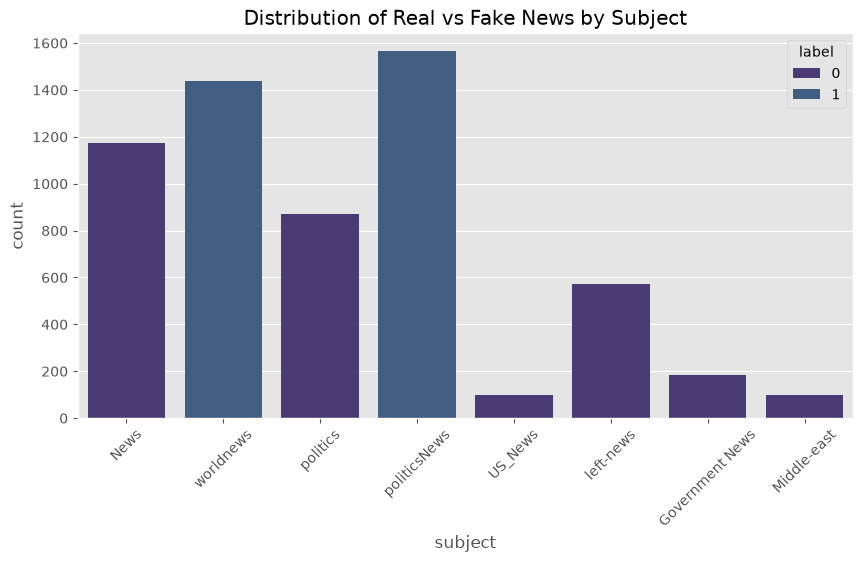

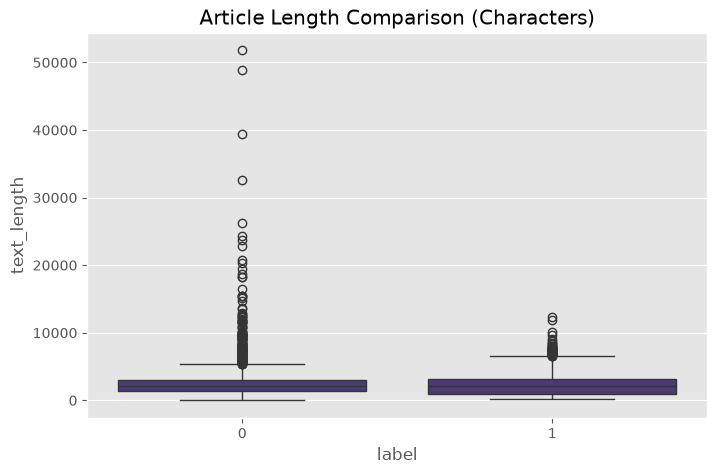

Average character length by label:
label
0    2549.141667
1    2371.724000
Name: text_length, dtype: float64


In [3]:
# 1. Category Distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='subject', hue='label')
plt.title('Distribution of Real vs Fake News by Subject')
plt.xticks(rotation=45)
plt.show()

# 2. Text Length Analysis
df['text_length'] = df['text'].astype(str).apply(len)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='label', y='text_length')
plt.title('Article Length Comparison (Characters)')
plt.show()

# Display average lengths
print("Average character length by label:")
print(df.groupby('label')['text_length'].mean())

* The boxplot above suggests that misinformation or sensationalized articles tend to use more descriptive, wordy, or emotionally padded text to make their arguments, whereas real journalism tends to be slightly more concise and direct.

In [4]:
# Separate features and target
X = df['text'].astype(str)
y = df['label']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert text into numerical values for model training
# Limit to 5000 features for memory and processing time
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

Model Accuracy: 97.17%

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       614
           1       0.96      0.98      0.97       586

    accuracy                           0.97      1200
   macro avg       0.97      0.97      0.97      1200
weighted avg       0.97      0.97      0.97      1200



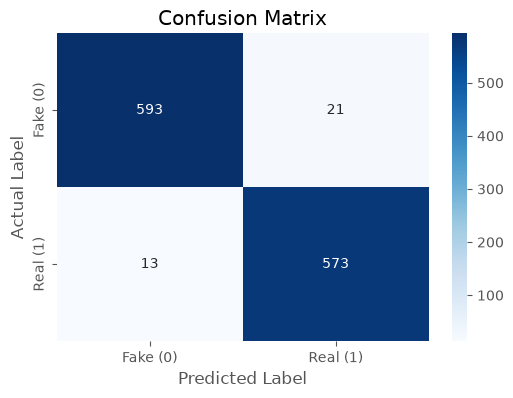

In [5]:
# Initialize and train a Logistic Regression model
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_tfidf)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fake (0)', 'Real (1)'], 
            yticklabels=['Fake (0)', 'Real (1)'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

* By training a Logistic Regression classifier, we achieved 97.17% accuracy. Out of 1,200 test articles, it only made a mistake 34 times.

In [6]:
# Extracting the feature names (words)
feature_names = np.array(vectorizer.get_feature_names_out())
coef = model.coef_[0]
top_real_idx = coef.argsort()[-10:][::-1]
top_fake_idx = coef.argsort()[:10]

print("Top 10 Words Indicating REAL News:")
print(feature_names[top_real_idx])
print("\nTop 10 Words Indicating FAKE News:")
print(feature_names[top_fake_idx])

Top 10 Words Indicating REAL News:
['said' 'reuters' 'washington' 'wednesday' 'tuesday' 'thursday'
 'republican' 'monday' 'minister' 'presidential']

Top 10 Words Indicating FAKE News:
['just' 'like' 'featured' 'hillary' 'image' 'com' 'america' 'obama' 'gop'
 'mr']


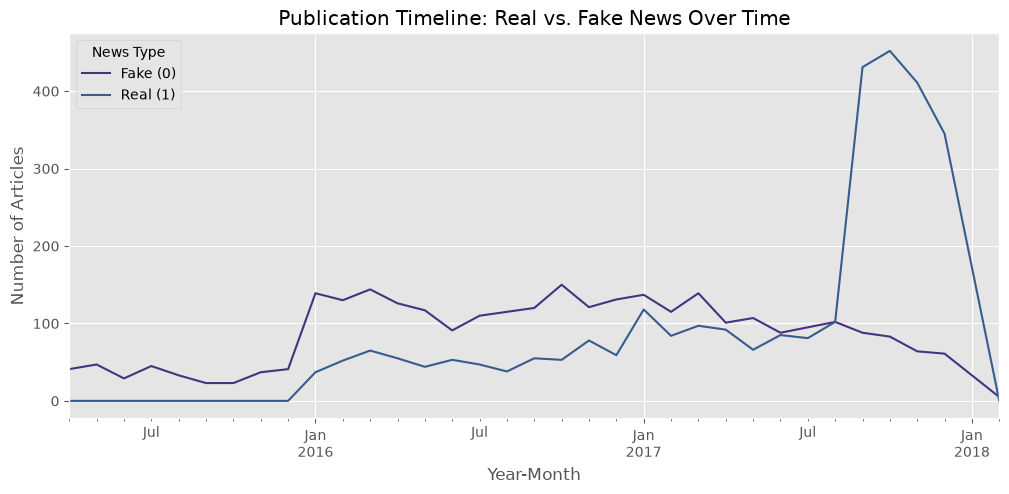

In [7]:
# Convert the date column with the mixed format to handle different date abbreviations
df['parsed_date'] = pd.to_datetime(df['date'], errors='coerce', format='mixed')
df['year_month'] = df['parsed_date'].dt.to_period('M')

# Group by Year-Month and Label to see publication volume over time
timeline_df = df.groupby(['year_month', 'label']).size().unstack(fill_value=0)

# Dynamically map the labels to clean names
column_mapping = {0: 'Fake (0)', 1: 'Real (1)'}
timeline_df = timeline_df.rename(columns=column_mapping)

# Plot temporal trends with both lines visible
plt.figure(figsize=(12, 5))
timeline_df.plot(kind='line', ax=plt.gca())
plt.title('Publication Timeline: Real vs. Fake News Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Number of Articles')
plt.legend(title='News Type')
plt.show()

* Real news (blue) and fake news (purple) follow completely different volume trends over time, highlighting that they were scraped or sampled from distinct publishing windows or news cycles.

* The 2017 Real News Spike: Notice the massive surge in real news articles starting around mid-2017 (peaking late 2017/early 2018). This shows a heavy concentration of real political/world reports during that specific period.

* Consistent Fake News Flow: Fake news publication volume remained relatively steady and stable throughout 2016 and early 2017, hovering mostly between 50 to 150 articles per month.

In [8]:
# Vectorize only the news titles (headlines) instead of the full text
title_vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X_titles_tfidf = title_vectorizer.fit_transform(df['title'].astype(str))

# Training a Logistic Regression model on titles alone
title_model = LogisticRegression()
title_model.fit(X_titles_tfidf, df['label'])

# Extract top headline words
title_features = np.array(title_vectorizer.get_feature_names_out())
title_coef = title_model.coef_[0]

top_real_title_idx = title_coef.argsort()[-10:][::-1]
top_fake_title_idx = title_coef.argsort()[:10]

print("Top 10 Headline Words Indicating REAL News:")
print(title_features[top_real_title_idx])
print("\nTop 10 Headline Words Indicating FAKE News:")
print(title_features[top_fake_title_idx])

Top 10 Headline Words Indicating REAL News:
['says' 'house' 'factbox' 'china' 'senate' 'lawmakers' 'eu' 'jerusalem'
 'ex' 'talks']

Top 10 Headline Words Indicating FAKE News:
['video' 'hillary' 'just' 'gop' 'breaking' 'watch' 'muslim' 'racist'
 'tweets' 'donald']


## Conclusion

### Linguistic Discrepancies
* **Real News Patterns:** Genuine articles heavily rely on standard journalistic formatting, proper attribution, and formal scheduling. The strongest identifying keywords for real news include: `said`, `reuters`, `washington`, `wednesday`, `tuesday`, `republican`, `minister`.
* **Fake News Patterns:** Misinformation leans significantly toward sensationalism, conversational phrasing, and emotionally charged opinions rather than strict reporting. The strongest identifying keywords for fake news include: `just`, `like`, `hillary`, `featured`, `image`, `gop`, `america`.

### Category Concentration
The dataset reveals strict structural differences in how news is categorized. Fake news is heavily concentrated in vaguely titled or subjective subject lines such as `News`, `politics`, and `left-news`. Verifiable real news is strictly categorized under explicit, formal headers like `politicsNews` and `worldnews`.

### Article Padding
Fake news articles are slightly longer on average, containing approximately **2,549 characters** compared to the **2,371 character** average of real news articles. This suggests that misinformation relies more on descriptive or inflammatory padding, whereas authentic journalism favors concise reporting.